In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px
import plotly.graph_objects as go

sns.set_style("whitegrid")

print("Libraries Loaded")

Libraries Loaded


In [3]:
base = "/content/drive/MyDrive/MutualFundAnalytics/data/raw/"

In [4]:
fund_master = pd.read_csv(base + "01_fund_master.csv")
nav = pd.read_csv(base + "02_nav_history.csv")
aum = pd.read_csv(base + "03_aum_by_fund_house.csv")
sip = pd.read_csv(base + "04_monthly_sip_inflows.csv")
cat = pd.read_csv(base + "05_category_inflows.csv")
folio = pd.read_csv(base + "06_industry_folio_count.csv")
perf = pd.read_csv(base + "07_scheme_performance.csv")
txn = pd.read_csv(base + "08_investor_transactions.csv")
holdings = pd.read_csv(base + "09_portfolio_holdings.csv")
benchmark = pd.read_csv(base + "10_benchmark_indices.csv")

print("All datasets loaded successfully")

All datasets loaded successfully


In [5]:
nav["date"] = pd.to_datetime(nav["date"])

nav_merged = nav.merge(
    fund_master[["amfi_code", "scheme_name"]],
    on="amfi_code"
)

print(nav_merged.head())

   amfi_code       date      nav                                scheme_name
0     119551 2022-01-03  54.3856  SBI Bluechip Fund - Regular Plan - Growth
1     119551 2022-01-04  54.3474  SBI Bluechip Fund - Regular Plan - Growth
2     119551 2022-01-05  54.6869  SBI Bluechip Fund - Regular Plan - Growth
3     119551 2022-01-06  55.4550  SBI Bluechip Fund - Regular Plan - Growth
4     119551 2022-01-07  55.3692  SBI Bluechip Fund - Regular Plan - Growth


In [6]:
fig = px.line(
    nav_merged,
    x="date",
    y="nav",
    color="scheme_name",
    title="Daily NAV Trend of Mutual Funds"
)

fig.show()

### Insight 1

Most mutual fund schemes exhibit a long-term upward NAV trend between 2022 and 2026, indicating sustained growth across the industry.


In [7]:
fig = px.line(
    nav_merged,
    x="date",
    y="nav",
    color="scheme_name",
    title="Daily NAV Trend with Market Events"
)

fig.add_vrect(
    x0="2023-01-01",
    x1="2023-12-31",
    fillcolor="green",
    opacity=0.15,
    annotation_text="2023 Bull Run",
    line_width=0
)

fig.add_vrect(
    x0="2024-01-01",
    x1="2024-06-30",
    fillcolor="red",
    opacity=0.15,
    annotation_text="2024 Correction",
    line_width=0
)

fig.show()

### Insight 2

Fund NAVs accelerated during the 2023 bull market period, while several schemes experienced slower growth during the 2024 correction phase.

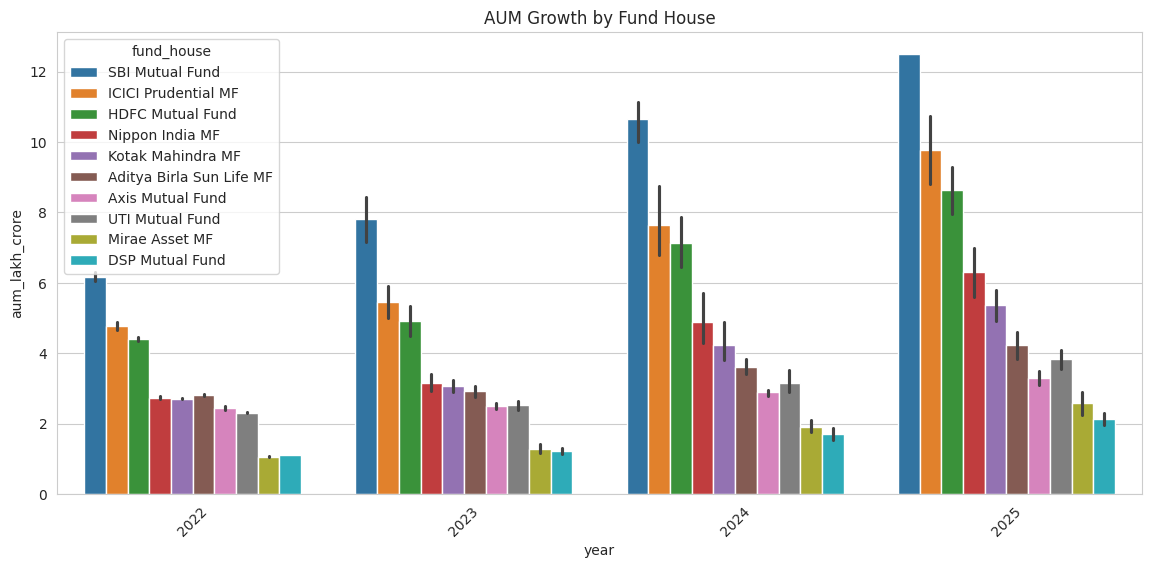

In [8]:
aum["date"] = pd.to_datetime(aum["date"])
aum["year"] = aum["date"].dt.year

plt.figure(figsize=(14,6))

sns.barplot(
    data=aum,
    x="year",
    y="aum_lakh_crore",
    hue="fund_house"
)

plt.title("AUM Growth by Fund House")
plt.xticks(rotation=45)

plt.show()

### Insight 3

SBI Mutual Fund maintained the highest Assets Under Management (AUM), reflecting strong investor confidence and market leadership.

In [9]:
sip["month"] = pd.to_datetime(sip["month"])

fig = px.line(
    sip,
    x="month",
    y="sip_inflow_crore",
    title="Monthly SIP Inflows (2022-2025)"
)

max_row = sip.loc[sip["sip_inflow_crore"].idxmax()]

fig.add_annotation(
    x=max_row["month"],
    y=max_row["sip_inflow_crore"],
    text=f"Peak: ₹{max_row['sip_inflow_crore']:,.0f} Cr",
    showarrow=True
)

fig.show()

### Insight 4

Monthly SIP inflows increased steadily throughout the study period, reaching an all-time high in late 2025, indicating growing retail investor participation.

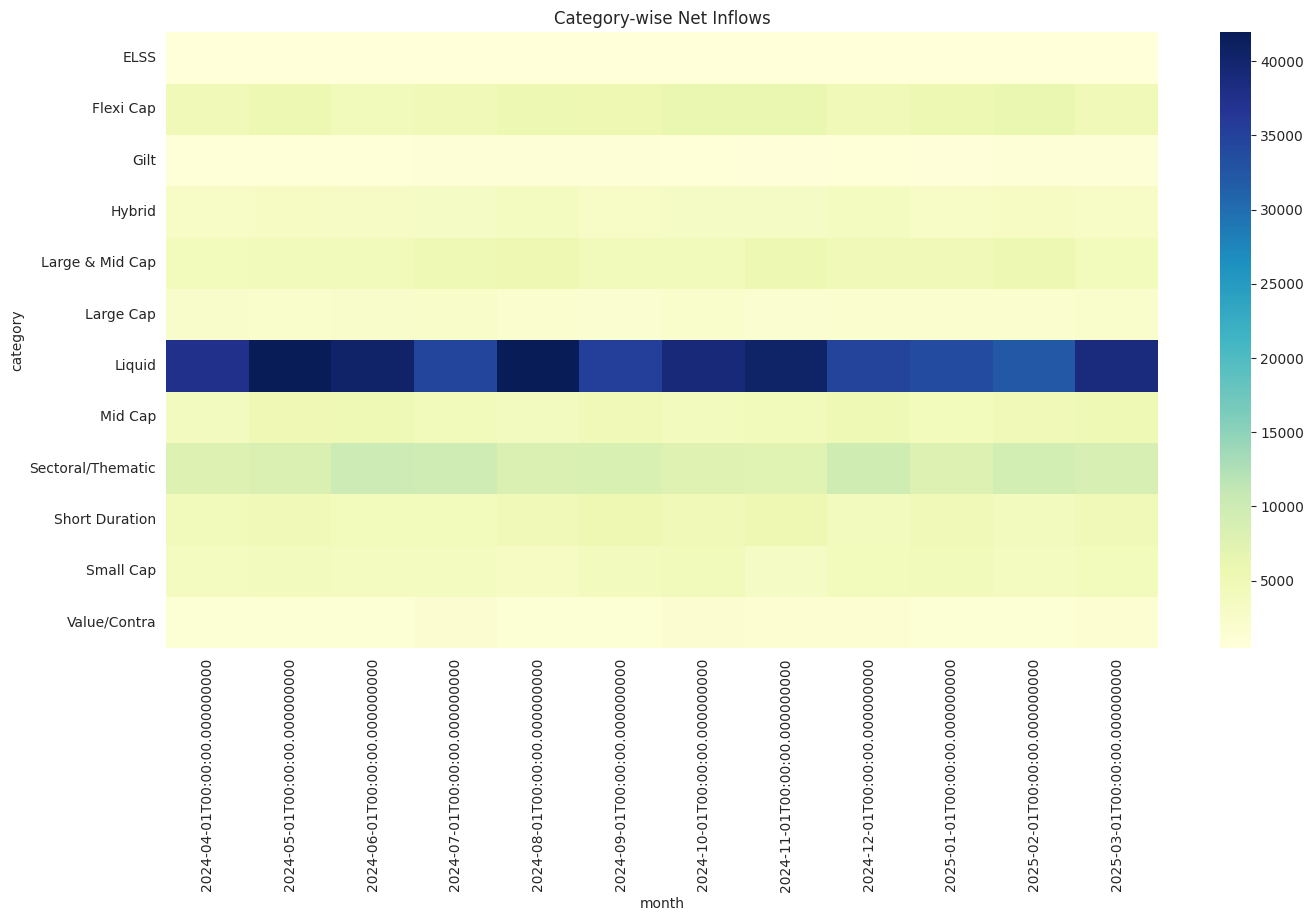

In [10]:
cat["month"] = pd.to_datetime(cat["month"])

heatmap_data = cat.pivot_table(
    index="category",
    columns="month",
    values="net_inflow_crore",
    aggfunc="sum"
)

plt.figure(figsize=(16,8))

sns.heatmap(
    heatmap_data,
    cmap="YlGnBu"
)

plt.title("Category-wise Net Inflows")
plt.show()

### Insight 5

Certain fund categories consistently attracted higher inflows, while others experienced periodic outflows depending on market sentiment.

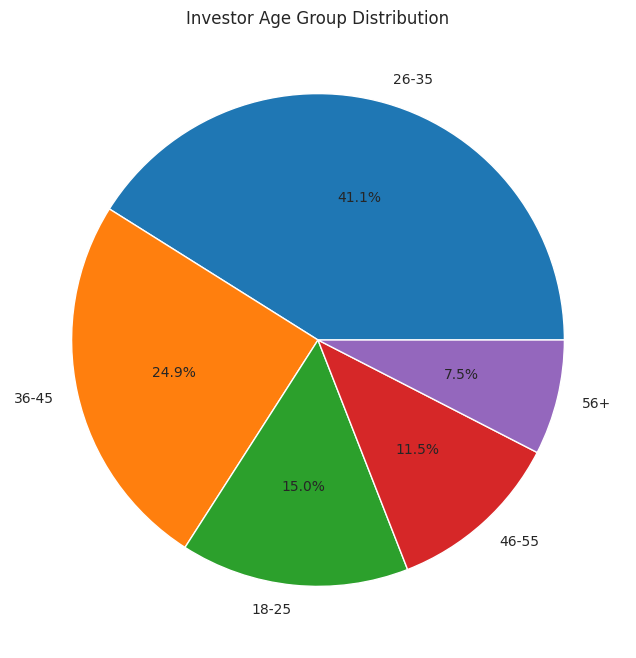

In [11]:
age_counts = txn["age_group"].value_counts()

plt.figure(figsize=(8,8))

plt.pie(
    age_counts,
    labels=age_counts.index,
    autopct="%1.1f%%"
)

plt.title("Investor Age Group Distribution")
plt.show()

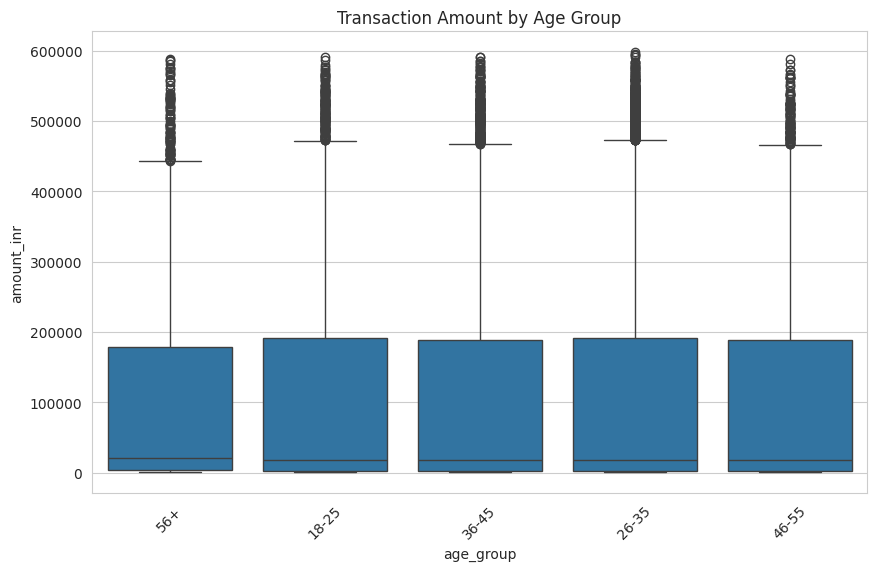

In [12]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=txn,
    x="age_group",
    y="amount_inr"
)

plt.title("Transaction Amount by Age Group")

plt.xticks(rotation=45)

plt.show()

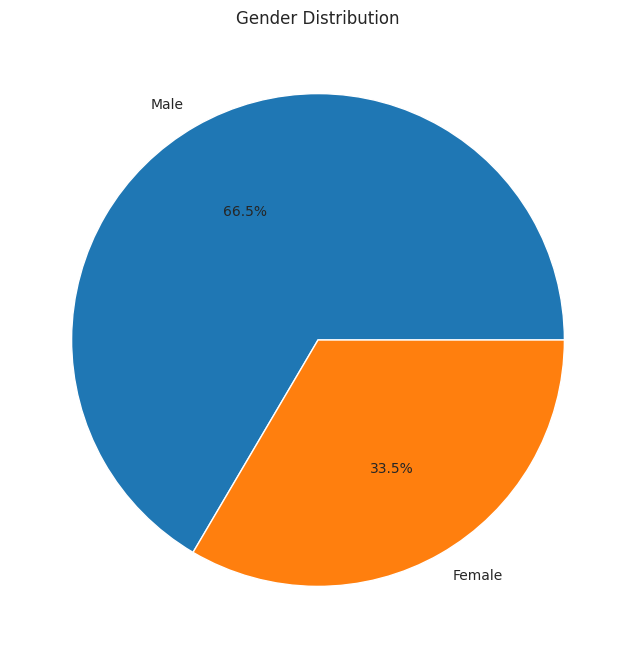

In [13]:
gender_counts = txn["gender"].value_counts()

plt.figure(figsize=(8,8))

plt.pie(
    gender_counts,
    labels=gender_counts.index,
    autopct="%1.1f%%"
)

plt.title("Gender Distribution")
plt.show()

### Insight 6

The majority of investors belong to working-age groups, with noticeable differences in investment behaviour across age segments and gender categories.

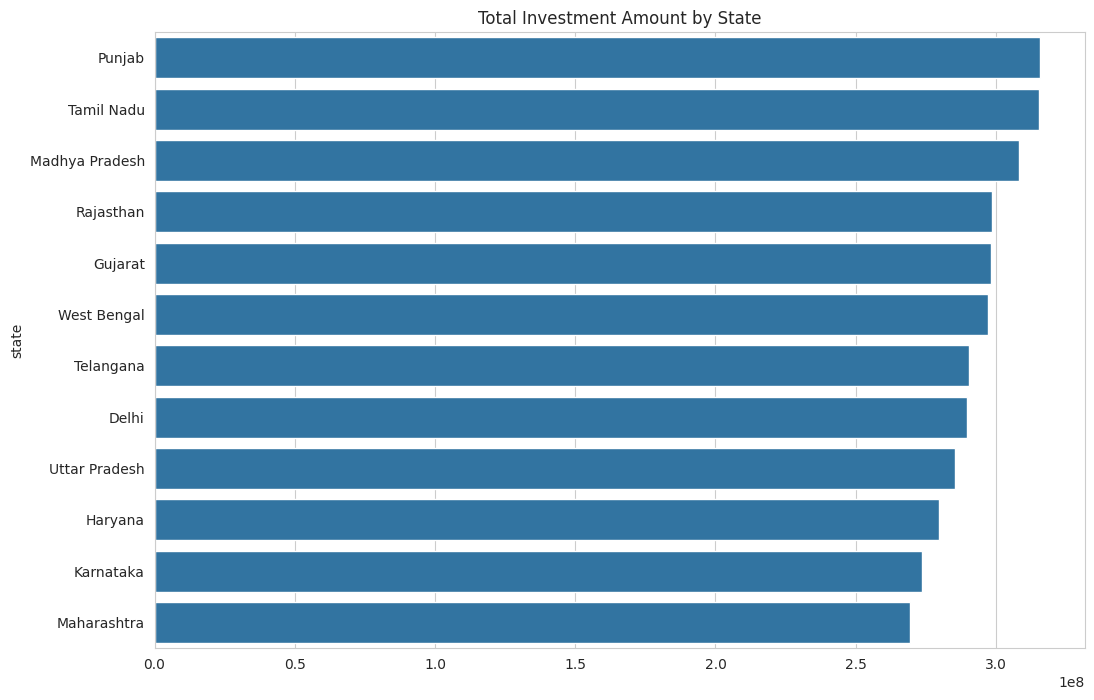

In [14]:
state_sip = (
    txn.groupby("state")["amount_inr"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(12,8))

sns.barplot(
    x=state_sip.values,
    y=state_sip.index
)

plt.title("Total Investment Amount by State")

plt.show()

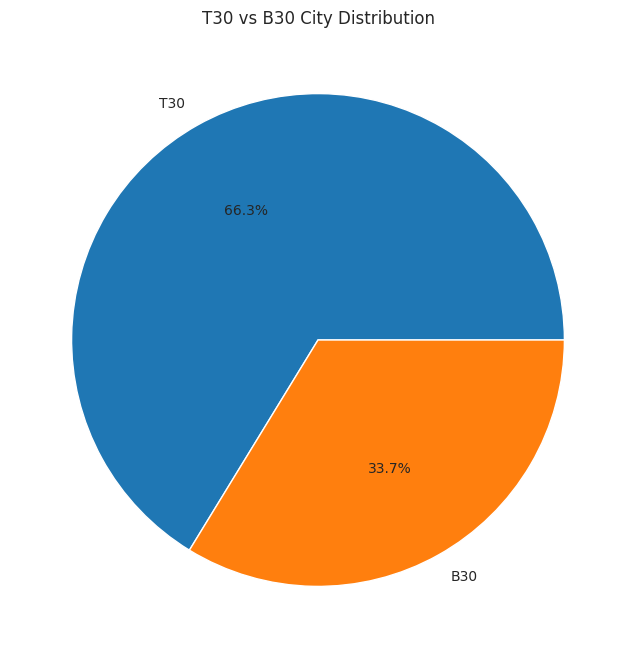

In [15]:
tier_counts = txn["city_tier"].value_counts()

plt.figure(figsize=(8,8))

plt.pie(
    tier_counts,
    labels=tier_counts.index,
    autopct="%1.1f%%"
)

plt.title("T30 vs B30 City Distribution")

plt.show()

### Insight 7

Investments remain concentrated in major urban centres, although participation from B30 cities continues to grow.

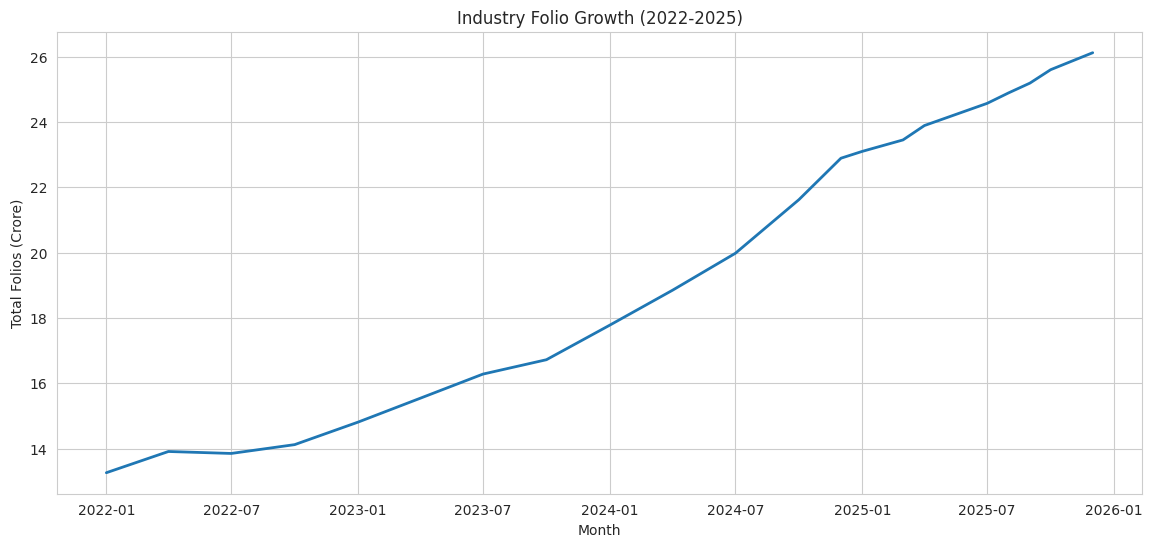

In [16]:
folio["month"] = pd.to_datetime(folio["month"])

plt.figure(figsize=(14,6))

plt.plot(
    folio["month"],
    folio["total_folios_crore"],
    linewidth=2
)

plt.title("Industry Folio Growth (2022-2025)")
plt.xlabel("Month")
plt.ylabel("Total Folios (Crore)")

plt.show()

### Insight 8

Total mutual fund folios increased significantly between 2022 and 2025, reflecting expanding retail participation in financial markets.


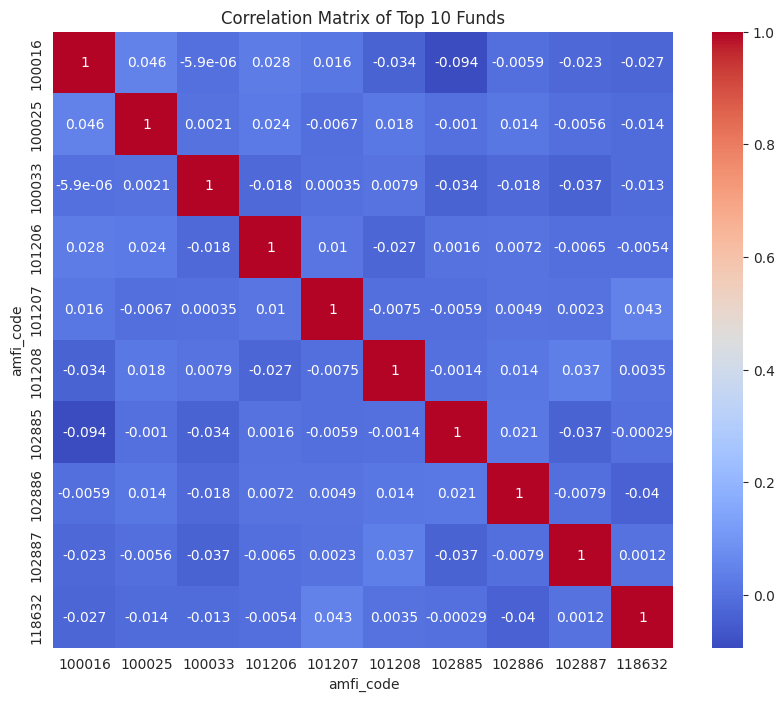

In [17]:
nav["date"] = pd.to_datetime(nav["date"])

pivot_nav = nav.pivot(
    index="date",
    columns="amfi_code",
    values="nav"
)

returns = pivot_nav.pct_change()

top10 = returns.columns[:10]

corr_matrix = returns[top10].corr()

plt.figure(figsize=(10,8))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Matrix of Top 10 Funds")

plt.show()

### Insight 9

Most diversified equity funds show positive correlations, indicating exposure to common market factors.

In [18]:
sector_data = (
    holdings.groupby("sector")["weight_pct"]
    .sum()
    .sort_values(ascending=False)
)

fig = px.pie(
    names=sector_data.index,
    values=sector_data.values,
    hole=0.5,
    title="Sector Allocation Across Equity Funds"
)

fig.show()

### Insight 10

Financials, Technology and Consumer sectors account for a significant portion of overall portfolio allocations.

# Conclusion

This exploratory data analysis examined mutual fund performance, investor participation, fund inflows, sector allocation and portfolio diversification patterns between 2022 and 2025.

Key observations include:

- Strong NAV growth across most schemes.
- Significant AUM concentration among leading fund houses.
- Consistent SIP growth over time.
- Increasing participation from retail investors.
- Growing folio counts across categories.
- Strong correlations among diversified equity schemes.
- Sector allocations concentrated in major economic sectors.

These findings provide a foundation for advanced performance analytics and portfolio optimisation in subsequent project stages.